<a href="https://colab.research.google.com/github/LailaBulh/Procesamiento_Lenguaje_Natural/blob/main/Analisis_texto_LB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Análisis de Texto**
**Nombre**: Laila Montserrat Bulhosen Ramos     **Matricula**: 263166

**Docente:** Dr. Rogelio Florencia Juarez

**Materia:** Procesamiento de Lenguaje Natural



**Objetivo:** Analizar el texto y aplicar técnicas de PLN.

**Link Github:** [Análisis de Texto](https://github.com/LailaBulh/Procesamiento_Lenguaje_Natural/blob/main/Analisis_texto_LB.ipynb)

**Fecha:** 27 febrero 2026

In [41]:
texto = """En el Congreso Internacional de Inteligencia Artificial 2025 se discutieron avances muy importantes.
@Maria comentó que la ética de la IA debe estar siempre en el centro de las investigaciones.
Puedes leer más en http://ia-congreso2025.org o enviar tus dudas al correo contacto@ia2025.org.
El Dr. Pérez afirmó: "¡La innovación no se detiene!". #InteligenciaArtificial #ÉticaDigital
Además, varios expertos señalaron que la inteligencia artificial, la inteligencia artificial
y la inteligencia artificial aparecen repetidamente en los debates académicos."""

print(texto)

En el Congreso Internacional de Inteligencia Artificial 2025 se discutieron avances muy importantes. 
@Maria comentó que la ética de la IA debe estar siempre en el centro de las investigaciones.
Puedes leer más en http://ia-congreso2025.org o enviar tus dudas al correo contacto@ia2025.org.
El Dr. Pérez afirmó: "¡La innovación no se detiene!". #InteligenciaArtificial #ÉticaDigital
Además, varios expertos señalaron que la inteligencia artificial, la inteligencia artificial
y la inteligencia artificial aparecen repetidamente en los debates académicos.


In [42]:
### Importacion de Librerias

import re

### **1. Extraer todas las direcciones de correo electrónico**

In [43]:
email = r'\S+@\S+'

print('Las direcciones de correo encontradas en el texto fueron:\n',re.findall(email, texto))

Las direcciones de correo encontradas en el texto fueron:
 ['contacto@ia2025.org.']


### **2. Extraer todas las URLs (con o sin protocolo)**

In [44]:
urls = r'http(?:\S+)?.org'

print('Las ligas encontradas en el texto fueron:\n', re.findall(urls, texto))

Las ligas encontradas en el texto fueron:
 ['http://ia-congreso2025.org']


### **3. Extraer hashtags.**

In [45]:
hashtag = r'#\w+'

print('Se encontraron los siguientes hashtags en el texto:\n', re.findall(hashtag, texto))

Se encontraron los siguientes hashtags en el texto:
 ['#InteligenciaArtificial', '#ÉticaDigital']


### **4. Identificar menciones**

In [46]:
tag = r'\s@\w+'
print('Se encontraron las siguientes menciones:\n', re.findall(tag, texto))

#tag2 = re.findall(tag, texto)
#print(tag2)

#tag_clean = re.escape(tag2)
#print(tag_clean)

#print('Se encontraron las siguientes menciones:\n', re.escape(tag2))

Se encontraron las siguientes menciones:
 ['\n@Maria']


### **5. Conversion a minúsculas**

In [47]:
txt_lowCase = texto.lower()

print(txt_lowCase)

en el congreso internacional de inteligencia artificial 2025 se discutieron avances muy importantes. 
@maria comentó que la ética de la ia debe estar siempre en el centro de las investigaciones.
puedes leer más en http://ia-congreso2025.org o enviar tus dudas al correo contacto@ia2025.org.
el dr. pérez afirmó: "¡la innovación no se detiene!". #inteligenciaartificial #éticadigital
además, varios expertos señalaron que la inteligencia artificial, la inteligencia artificial
y la inteligencia artificial aparecen repetidamente en los debates académicos.


### **6. Eliminar puntuaciones**

In [48]:
puntuaciones = re.sub(r'[^\w\s]', '', txt_lowCase)

print(puntuaciones)

en el congreso internacional de inteligencia artificial 2025 se discutieron avances muy importantes 
maria comentó que la ética de la ia debe estar siempre en el centro de las investigaciones
puedes leer más en httpiacongreso2025org o enviar tus dudas al correo contactoia2025org
el dr pérez afirmó la innovación no se detiene inteligenciaartificial éticadigital
además varios expertos señalaron que la inteligencia artificial la inteligencia artificial
y la inteligencia artificial aparecen repetidamente en los debates académicos


### **7. Lematizacion**

In [49]:
import spacy

In [50]:
!python -m spacy download es_core_news_sm
!python -m spacy link fr_core_news_sm fr


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 73.0 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
⚠ As of spaCy v3.0, model symlinks are not supported anymore. You can
load trained pipeline packages using their full names or from a directory
path.


In [51]:
nlp = spacy.load('es_core_news_sm')

texto2 = nlp(puntuaciones)

print('Spacy lematización:\n')
for token in texto2:
  print(token.text, '->', token.lemma_)


Spacy lematización:

en -> en
el -> el
congreso -> congreso
internacional -> internacional
de -> de
inteligencia -> inteligencia
artificial -> artificial
2025 -> 2025
se -> él
discutieron -> discutir
avances -> avance
muy -> mucho
importantes -> importante

 -> 

maria -> mario
comentó -> comentar
que -> que
la -> el
ética -> ética
de -> de
la -> el
ia -> ia
debe -> deber
estar -> estar
siempre -> siempre
en -> en
el -> el
centro -> centro
de -> de
las -> el
investigaciones -> investigación

 -> 

puedes -> poder
leer -> leer
más -> más
en -> en
httpiacongreso2025org -> httpiacongreso2025org
o -> o
enviar -> enviar
tus -> tu
dudas -> duda
al -> al
correo -> correo
contactoia2025org -> contactoia2025org

 -> 

el -> el
dr -> dr
pérez -> pérez
afirmó -> afirmar
la -> el
innovación -> innovación
no -> no
se -> él
detiene -> detener
inteligenciaartificial -> inteligenciaartificial
éticadigital -> éticadigital

 -> 

además -> además
varios -> varios
expertos -> experto
señalaron -> señalar

### **8.Remover stopwords**

In [52]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

In [53]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [54]:
tokens = word_tokenize(puntuaciones, language = 'spanish')

print('Tokens:\n', tokens)

Tokens:
 ['en', 'el', 'congreso', 'internacional', 'de', 'inteligencia', 'artificial', '2025', 'se', 'discutieron', 'avances', 'muy', 'importantes', 'maria', 'comentó', 'que', 'la', 'ética', 'de', 'la', 'ia', 'debe', 'estar', 'siempre', 'en', 'el', 'centro', 'de', 'las', 'investigaciones', 'puedes', 'leer', 'más', 'en', 'httpiacongreso2025org', 'o', 'enviar', 'tus', 'dudas', 'al', 'correo', 'contactoia2025org', 'el', 'dr', 'pérez', 'afirmó', 'la', 'innovación', 'no', 'se', 'detiene', 'inteligenciaartificial', 'éticadigital', 'además', 'varios', 'expertos', 'señalaron', 'que', 'la', 'inteligencia', 'artificial', 'la', 'inteligencia', 'artificial', 'y', 'la', 'inteligencia', 'artificial', 'aparecen', 'repetidamente', 'en', 'los', 'debates', 'académicos']


In [55]:
stop_words = set(stopwords.words('spanish'))

tokens_filtrados = [word for word in tokens if word not in stop_words and word.isalpha()]
print(tokens_filtrados)

['congreso', 'internacional', 'inteligencia', 'artificial', 'discutieron', 'avances', 'importantes', 'maria', 'comentó', 'ética', 'ia', 'debe', 'siempre', 'centro', 'investigaciones', 'puedes', 'leer', 'enviar', 'dudas', 'correo', 'dr', 'pérez', 'afirmó', 'innovación', 'detiene', 'inteligenciaartificial', 'éticadigital', 'además', 'varios', 'expertos', 'señalaron', 'inteligencia', 'artificial', 'inteligencia', 'artificial', 'inteligencia', 'artificial', 'aparecen', 'repetidamente', 'debates', 'académicos']


### **9. Frecuencia de palabras**

In [56]:
from collections import Counter

In [57]:
frecuency = Counter(tokens_filtrados)

print('Frecuencia de las palabras:\n')
display(frecuency)

Frecuencia de las palabras:



Counter({'congreso': 1,
         'internacional': 1,
         'inteligencia': 4,
         'artificial': 4,
         'discutieron': 1,
         'avances': 1,
         'importantes': 1,
         'maria': 1,
         'comentó': 1,
         'ética': 1,
         'ia': 1,
         'debe': 1,
         'siempre': 1,
         'centro': 1,
         'investigaciones': 1,
         'puedes': 1,
         'leer': 1,
         'enviar': 1,
         'dudas': 1,
         'correo': 1,
         'dr': 1,
         'pérez': 1,
         'afirmó': 1,
         'innovación': 1,
         'detiene': 1,
         'inteligenciaartificial': 1,
         'éticadigital': 1,
         'además': 1,
         'varios': 1,
         'expertos': 1,
         'señalaron': 1,
         'aparecen': 1,
         'repetidamente': 1,
         'debates': 1,
         'académicos': 1})

### **10. Nube de palabras**

In [58]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

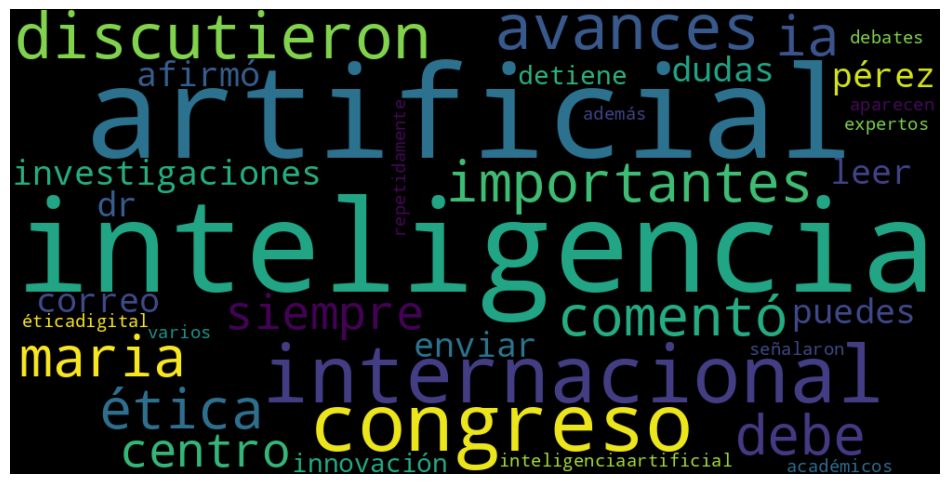

In [59]:
plt.figure(figsize = (12,8))

wordcloud_im = WordCloud(width= 1000, height= 500, background_color= 'black', collocations= False).generate_from_frequencies(frecuency)
plt.imshow(wordcloud_im, interpolation= 'bilinear')
plt.axis('off')
plt.show()